# Build a Perceptron from Scratch

The perceptron is one of the earliest trainable models in artificial intelligence. In this tutorial, we will implement one with NumPy and teach it the logical **AND** function.

## Goal

By the end of this notebook, you will be able to:

- explain how a perceptron turns inputs into a binary prediction;
- implement its training rule from scratch;
- train and verify a model on AND and OR gates; and
- understand why a single perceptron cannot learn XOR.

## Setup

Only NumPy and Matplotlib are required. NumPy handles vectors and Matplotlib draws the learned decision boundary.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## Steps

### 1. Create the AND dataset

AND returns `1` only when both inputs are `1`. Each row of `X` is one example, and the corresponding element of `y` is its correct label.

In [12]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=float)

y_and = np.array([0, 0, 0, 1])

print("x1  x2  AND")
for inputs, label in zip(X.astype(int), y_and):
    print(f" {inputs[0]}   {inputs[1]}    {label}")

x1  x2  AND
 0   0    0
 0   1    0
 1   0    0
 1   1    1


### 2. Understand the calculation

A perceptron first computes a weighted sum:

$$z = x \cdot w + b$$

It then applies a step function:

$$\hat{y} = \begin{cases}1 & z \geq 0 \\ 0 & z < 0\end{cases}$$

After each prediction, it adjusts its weights and bias using the error $y-\hat{y}$:

$$w \leftarrow w + \eta(y-\hat{y})x$$
$$b \leftarrow b + \eta(y-\hat{y})$$

Here, $\eta$ is the learning rate.

### 3. Implement the perceptron

Notice the line `_, number_of_features = X.shape`. `X.shape` contains both the number of samples and the number of features. We need **one weight per feature**, not a matrix shaped like the whole dataset.

To keep this first implementation simple, it assumes `X` is a two-dimensional NumPy array, `y` has one binary label per row, and `fit` is called before `predict`.

In [13]:
class Perceptron:
    """A binary perceptron implemented with NumPy."""

    def __init__(self, learning_rate=0.1, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0.0
        self.errors_per_epoch = []

    def weighted_sum(self, inputs):
        return np.dot(inputs, self.weights) + self.bias

    @staticmethod
    def activation_function(weighted_sum):
        predictions = (np.asarray(weighted_sum) >= 0).astype(int)
        return int(predictions) if predictions.ndim == 0 else predictions

    def predict(self, inputs):
        return self.activation_function(self.weighted_sum(inputs))

    def fit(self, X, y, verbose=True):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        _, number_of_features = X.shape
        self.weights = np.zeros(number_of_features)
        self.bias = 0.0
        self.errors_per_epoch = []
    

        for epoch in range(self.epochs):
            total_error = 0

            for inputs, label in zip(X, y):
                prediction = self.predict(inputs)
                error = label - prediction

                self.weights += self.learning_rate * error * inputs
                self.bias += self.learning_rate * error
                total_error += abs(error)

            self.errors_per_epoch.append(int(total_error))
            if verbose:
                print(
                    f"Epoch {epoch + 1:>2}: errors={total_error}, "
                    f"weights={self.weights}, bias={self.bias:.3f}"
                )

            if total_error == 0:
                break

      

        return self


### 4. Train the model

One **epoch** is one complete pass through the training examples. Training stops early when the model makes no errors in an epoch.

In [14]:
and_model = Perceptron(learning_rate=0.1, epochs=20)
and_model.fit(X, y_and);


Epoch  1: errors=2, weights=[0.1 0.1], bias=0.000
Epoch  2: errors=3, weights=[0.2 0.1], bias=-0.100
Epoch  3: errors=3, weights=[0.2 0.1], bias=-0.200
Epoch  4: errors=0, weights=[0.2 0.1], bias=-0.200


### 5. Inspect the learned model

The two learned weights describe the importance of the two inputs. The bias shifts the decision boundary.

In [15]:
and_predictions = and_model.predict(X)

print(f"Weights:     {and_model.weights}")
print(f"Bias:        {and_model.bias:.3f}")
print(f"Expected:    {y_and}")
print(f"Predictions: {and_predictions}")

Weights:     [0.2 0.1]
Bias:        -0.200
Expected:    [0 0 0 1]
Predictions: [0 0 0 1]


### 6. Visualize the decision boundary

Points above one side of the line are classified as `1`; points on the other side are classified as `0`.

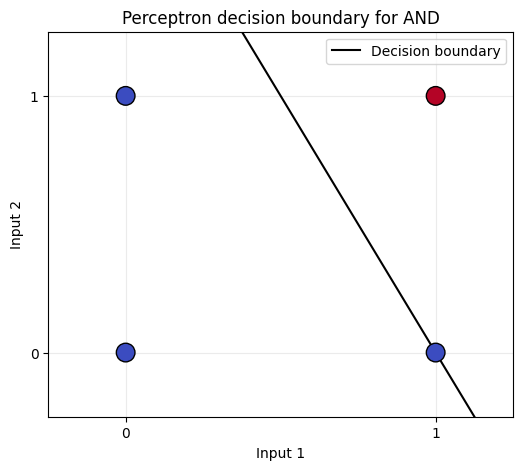

In [16]:
figure, axis = plt.subplots(figsize=(6, 5))
axis.scatter(
    X[:, 0], X[:, 1],
    c=y_and, cmap="coolwarm", s=180, edgecolor="black", zorder=3
)

x_values = np.linspace(-0.25, 1.25, 100)
w1, w2 = and_model.weights
y_values = -(w1 * x_values + and_model.bias) / w2
axis.plot(x_values, y_values, color="black", label="Decision boundary")

axis.set(
    xlim=(-0.25, 1.25), ylim=(-0.25, 1.25),
    xlabel="Input 1", ylabel="Input 2",
    title="Perceptron decision boundary for AND",
)
axis.set_xticks([0, 1])
axis.set_yticks([0, 1])
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## Checks

Assertions make the notebook fail loudly if the implementation stops behaving correctly.

In [17]:
correct_weight_shape = and_model.weights.shape == (X.shape[1],)
correct_predictions = np.array_equal(and_predictions, y_and)
and_accuracy = np.mean(and_predictions == y_and)

print(f"Correct weight shape: {correct_weight_shape}")
print(f"Predictions match:    {correct_predictions}")
print(f"AND accuracy:         {and_accuracy:.0%}")

Correct weight shape: True
Predictions match:    True
AND accuracy:         100%


### Try another linearly separable problem: OR

OR returns `1` when either input is `1`. The same implementation should learn it without any code changes.

In [18]:
y_or = np.array([0, 1, 1, 1])
or_model = Perceptron(learning_rate=0.1, epochs=20).fit(X, y_or, verbose=False)
or_predictions = or_model.predict(X)

print(f"Expected OR:    {y_or}")
print(f"Predicted OR:   {or_predictions}")
print(f"Predictions match: {np.array_equal(or_predictions, y_or)}")

Expected OR:    [0 1 1 1]
Predicted OR:   [0 1 1 1]
Predictions match: True


### Discover the limitation: XOR

A single straight line cannot separate the `1` outputs of XOR from its `0` outputs. A single perceptron therefore cannot learn XOR perfectly, no matter how many epochs it receives. This limitation helped motivate multilayer neural networks.

In [19]:
y_xor = np.array([0, 1, 1, 0])
xor_model = Perceptron(learning_rate=0.1, epochs=20).fit(X, y_xor, verbose=False)
xor_predictions = xor_model.predict(X)
xor_accuracy = np.mean(xor_predictions == y_xor)
print(f"Expected XOR:  {y_xor}")
print(f"Predicted XOR: {xor_predictions}")
print(f"XOR accuracy after 20 epochs: {xor_accuracy:.0%}")

Expected XOR:  [0 1 1 0]
Predicted XOR: [1 1 0 0]
XOR accuracy after 20 epochs: 50%


## Next Steps

You now have a perceptron that learns linearly separable binary patterns.

Try these extensions:

1. Change the learning rate and observe how many epochs training needs.
2. Shuffle the training examples at the start of each epoch.
3. Add a plot of `errors_per_epoch` to show the learning process.
4. Build a small multilayer network that can learn XOR.

The standalone version of the model is available in `perceptron.py`.